In [1]:
import sys
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add dirctory with model moduels to path
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

import CIBUSmod as cm
from CIBUSmod.utils.output_data_manip import concat_herds

# Create input data
x0_crp.csv and x0_ani.csv represent the current areas of different crops and number of heads of different animals respectively. These are both still WIP, which is why some mangling is needed here to get them in the right form.
The demand vector is generated with demand for cattle meat, pig meat and cattle milk equal to what is in the agricultural statistics.

In [2]:
# Define x0_crp
# Define x0_crp
x0_crp = \
    pd.read_csv(os.path.join('..','data','x0','x0_crp.csv'), dtype={'region': object})\
    .set_index(['crop','prod_system','region'])['area']

# Define x0_ani
x0_ani = pd.read_csv(os.path.join('..','data','x0','x0_ani.csv'), dtype={'region': object})

x0_ani['species'] = np.nan
x0_ani['species'] = \
np.where(np.isin(x0_ani['animal'], ['kor för mjölkproduktion', 'kor för uppfödning av kalvar']),'cattle',x0_ani['species'])
x0_ani['species'] = \
np.where(x0_ani['animal']=='suggor för avel','pigs',x0_ani['species'])

x0_ani['breed'] = np.nan
x0_ani['breed'] = \
np.where(x0_ani['animal']=='kor för mjölkproduktion','dairy',x0_ani['breed'])
x0_ani['breed'] = \
np.where(x0_ani['animal']=='kor för uppfödning av kalvar','beef',x0_ani['breed'])
x0_ani['breed'] = \
np.where(x0_ani['animal']=='suggor för avel','none',x0_ani['breed'])

x0_ani = x0_ani[x0_ani['species']!='nan'][['species','breed','prod_system','region','number']].set_index(['species','breed','prod_system','region'])['number']

x0_ani = x0_ani.fillna(0)

x0 = {'ani':x0_ani,'crp':x0_crp}

# Run test scenario 'baseline'
This test scenario includes ...
1. A 0.6% year-on-year increase in population (parameter='population'),
1. a 6% increase in milk yield per cow  per every 5 years (parameter='milk_prod'),
2. an overall yield increase of 5% from 2020 to 2050 for all crops (parameter='yield'),
3. a 1% year-on-year decrease in pig meat consumption up until 2040 (parameter='consumption').

The scenario is defined in the different parameter Excel files in 'data/production_parameters' under the sheets named 'scn_baseline'

Note: Warnings are printed as the scenario is not defined in all parameter Excel files.

## Run model

In [115]:
tic = time.time()

# Define scenario, years and create output container
scn = 'baseline'
years = ['2020','2030','2040','2050']
output = pd.DataFrame(
    columns=['crp','ani'],
    index=pd.MultiIndex.from_frame(pd.DataFrame({'scn':scn,'year':years}))
)

# Instantiate diet class
diet = cm.Diet(
    par = cm.ParameterRetriever(
        os.path.join('..','data','prod_parameters','Diet.xlsx')
    )
)

# Instantiate crop production
crops = cm.CropProduction(
    par = cm.ParameterRetriever(
        os.path.join('..','data','prod_parameters','CropProduction.xlsx')
    ),
    index = x0_crp.index
)    

# Instantiate animal herds
herds=pd.Series(
    data=[],
    index=pd.MultiIndex(
        levels=[[]]*4,
        codes=[[]]*4,
        names=['species','breed','prod_system','sub_system']
    ),
    dtype = object
)

for (sp,br,ps) in x0_ani.groupby(['species','breed','prod_system']).sum().index:
            
    if sp == 'cattle':
        for ss in ['maize based','none'] if (ps == 'conventional') else ['none']:
            herds[(sp,br,ps,ss)] = \
                cm.CattleHerd(
                    par = cm.ParameterRetriever(
                        os.path.join('..','data','prod_parameters','CattleHerd.xlsx')
                    ),
                    index = x0_ani.index.get_level_values('region').unique(),
                    breed = br,
                    prod_system = ps,
                    sub_system = ss
                )

    elif sp == 'pigs':
        herds[(sp,br,ps,'none')] = \
            cm.PigHerd(
                par = cm.ParameterRetriever(
                    os.path.join('..','data','prod_parameters','PigHerd.xlsx')
                ),
                index = x0_ani.index.get_level_values('region').unique(),
                breed = br,
                prod_system = ps
            ) 

# Instantiate feed management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever(
        os.path.join('..','data','prod_parameters','FeedMgmt.xlsx')
    )
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    par = cm.ParameterRetriever(
        os.path.join('..','data','prod_parameters','ManureMgmt.xlsx')
    )
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(x0,diet,crops,herds,feed_mgmt)

# Loop through years
for year in years:
    print(year)
    
    # Update all parameter values
    cm.ParameterRetriever.update_all_parameter_values(scn,year)
    
    # Calculate food demand
    diet.calculate(verbose=True)

    # Calculate crops
    crops.calculate(
        verbose = True
    )

    # Calculate herds
    for h in herds:
        h.calculate(verbose = True)

    # Calculate feed
    feed_mgmt.calculate(verbose=True)    

    # Calculate manure
    manure_mgmt.calculate(verbose=True)

    # Distribute animals and crops
    # Make optimisation problem
    geodist.make(use_cons=[1,2,3,4,6], scale_power=[0.25,0], verbose=True)
    # Solve optimisation problem
    geodist.solve(
        verbose=True,
        solver_settings = {
            'solver':'OSQP',
            'max_iter':200000,
            'eps_abs':1e-6,
            'eps_rel':1e-6,
            'verbose':False
        }
    )

    # Scale and append results
    output.loc[(scn,year),'crp'] = crops.scale(geodist.x['crp'])
    
    output.loc[(scn,year),'ani'] = concat_herds([
        h.scale(
            geodist.x['ani'].loc[(h.species,h.breed,h.prod_system,h.sub_system)],
            x_is = h.x_is
        )
        for h in herds
    ])

print(f'Done! Elapsed time: {(time.time()-tic):.0f} sec')

2020


C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:237: UserWarning: No sheet named 'scn_baseline' found in '..\data\prod_parameters\PigHerd.xlsx'. No parameter values were updated according to this scenario.
  warnings.warn(f"No sheet named 'scn_{scn}' found in '{self.path}'. No parameter values were updated according to this scenario.")
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:237: UserWarning: No sheet named 'scn_baseline' found in '..\data\prod_parameters\FeedMgmt.xlsx'. No parameter values were updated according to this scenario.
  warnings.warn(f"No sheet named 'scn_{scn}' found in '{self.path}'. No parameter values were updated according to this scenario.")
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:237: UserWarning: No sh

[11:06:47][Diet] Calculating food demand ...
[11:06:47][Diet] Calculating waste ...
[11:06:47][Diet] Calculating crop product demand ...
[11:06:47][Diet] Calculating crop product demand ...
[11:06:47][Diet] Done! Elapsed time: 1 sec
[11:06:47][CropProduction] Calculating harvest ...
[11:06:47][CropProduction] Calculating production ...
[11:06:51][CropProduction] Calculating seed demand ...
[11:06:53][CropProduction] Done! Elapsed time: 6 sec
[11:06:53][AnimalHerd (cattle, beef, conventional, maize based)] Calculating herd structure ...
[11:06:54][AnimalHerd (cattle, beef, conventional, maize based)] Calculating production ...
[11:06:54][AnimalHerd (cattle, beef, conventional, maize based)] Done! Elapsed time: 0 sec
[11:06:54][AnimalHerd (cattle, beef, conventional, none)] Calculating herd structure ...
[11:06:54][AnimalHerd (cattle, beef, conventional, none)] Calculating production ...
[11:06:54][AnimalHerd (cattle, beef, conventional, none)] Done! Elapsed time: 0 sec
[11:06:54][Animal

C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:237: UserWarning: No sheet named 'scn_baseline' found in '..\data\prod_parameters\PigHerd.xlsx'. No parameter values were updated according to this scenario.
  warnings.warn(f"No sheet named 'scn_{scn}' found in '{self.path}'. No parameter values were updated according to this scenario.")
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:237: UserWarning: No sheet named 'scn_baseline' found in '..\data\prod_parameters\FeedMgmt.xlsx'. No parameter values were updated according to this scenario.
  warnings.warn(f"No sheet named 'scn_{scn}' found in '{self.path}'. No parameter values were updated according to this scenario.")
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:237: UserWarning: No sh

[11:08:52][Diet] Calculating food demand ...
[11:08:52][Diet] Calculating waste ...
[11:08:52][Diet] Calculating crop product demand ...
[11:08:52][Diet] Calculating crop product demand ...
[11:08:52][Diet] Done! Elapsed time: 1 sec
[11:08:52][CropProduction] Calculating harvest ...
[11:08:52][CropProduction] Calculating production ...
[11:08:56][CropProduction] Calculating seed demand ...
[11:08:58][CropProduction] Done! Elapsed time: 6 sec
[11:08:58][AnimalHerd (cattle, beef, conventional, maize based)] Calculating herd structure ...
[11:08:58][AnimalHerd (cattle, beef, conventional, maize based)] Calculating production ...
[11:08:58][AnimalHerd (cattle, beef, conventional, maize based)] Done! Elapsed time: 0 sec
[11:08:58][AnimalHerd (cattle, beef, conventional, none)] Calculating herd structure ...
[11:08:59][AnimalHerd (cattle, beef, conventional, none)] Calculating production ...
[11:08:59][AnimalHerd (cattle, beef, conventional, none)] Done! Elapsed time: 0 sec
[11:08:59][Animal

C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:237: UserWarning: No sheet named 'scn_baseline' found in '..\data\prod_parameters\PigHerd.xlsx'. No parameter values were updated according to this scenario.
  warnings.warn(f"No sheet named 'scn_{scn}' found in '{self.path}'. No parameter values were updated according to this scenario.")
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:237: UserWarning: No sheet named 'scn_baseline' found in '..\data\prod_parameters\FeedMgmt.xlsx'. No parameter values were updated according to this scenario.
  warnings.warn(f"No sheet named 'scn_{scn}' found in '{self.path}'. No parameter values were updated according to this scenario.")
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:237: UserWarning: No sh

[11:10:49][Diet] Calculating food demand ...
[11:10:49][Diet] Calculating waste ...
[11:10:49][Diet] Calculating crop product demand ...
[11:10:49][Diet] Calculating crop product demand ...
[11:10:49][Diet] Done! Elapsed time: 1 sec
[11:10:49][CropProduction] Calculating harvest ...
[11:10:49][CropProduction] Calculating production ...
[11:10:53][CropProduction] Calculating seed demand ...
[11:10:55][CropProduction] Done! Elapsed time: 5 sec
[11:10:55][AnimalHerd (cattle, beef, conventional, maize based)] Calculating herd structure ...
[11:10:55][AnimalHerd (cattle, beef, conventional, maize based)] Calculating production ...
[11:10:55][AnimalHerd (cattle, beef, conventional, maize based)] Done! Elapsed time: 0 sec
[11:10:55][AnimalHerd (cattle, beef, conventional, none)] Calculating herd structure ...
[11:10:55][AnimalHerd (cattle, beef, conventional, none)] Calculating production ...
[11:10:56][AnimalHerd (cattle, beef, conventional, none)] Done! Elapsed time: 0 sec
[11:10:56][Animal

C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:237: UserWarning: No sheet named 'scn_baseline' found in '..\data\prod_parameters\PigHerd.xlsx'. No parameter values were updated according to this scenario.
  warnings.warn(f"No sheet named 'scn_{scn}' found in '{self.path}'. No parameter values were updated according to this scenario.")
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:237: UserWarning: No sheet named 'scn_baseline' found in '..\data\prod_parameters\FeedMgmt.xlsx'. No parameter values were updated according to this scenario.
  warnings.warn(f"No sheet named 'scn_{scn}' found in '{self.path}'. No parameter values were updated according to this scenario.")
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:237: UserWarning: No sh

[11:12:56][Diet] Calculating food demand ...
[11:12:56][Diet] Calculating waste ...
[11:12:56][Diet] Calculating crop product demand ...
[11:12:56][Diet] Calculating crop product demand ...
[11:12:56][Diet] Done! Elapsed time: 1 sec
[11:12:56][CropProduction] Calculating harvest ...
[11:12:56][CropProduction] Calculating production ...
[11:13:00][CropProduction] Calculating seed demand ...
[11:13:01][CropProduction] Done! Elapsed time: 5 sec
[11:13:01][AnimalHerd (cattle, beef, conventional, maize based)] Calculating herd structure ...
[11:13:02][AnimalHerd (cattle, beef, conventional, maize based)] Calculating production ...
[11:13:02][AnimalHerd (cattle, beef, conventional, maize based)] Done! Elapsed time: 0 sec
[11:13:02][AnimalHerd (cattle, beef, conventional, none)] Calculating herd structure ...
[11:13:02][AnimalHerd (cattle, beef, conventional, none)] Calculating production ...
[11:13:03][AnimalHerd (cattle, beef, conventional, none)] Done! Elapsed time: 1 sec
[11:13:03][Animal

## Plot output

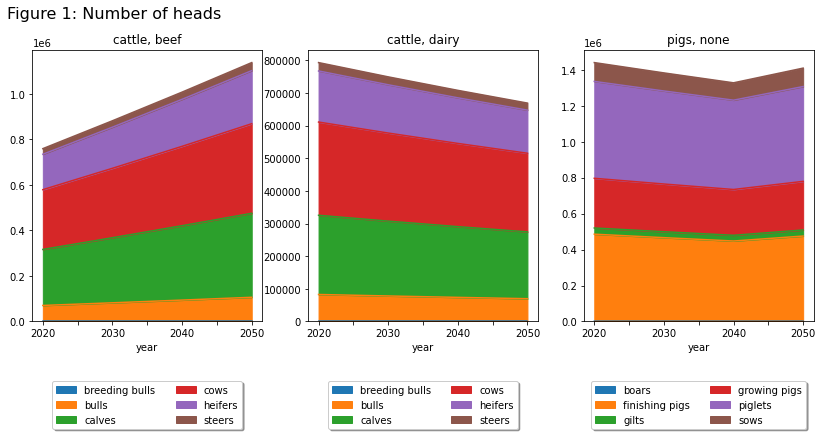

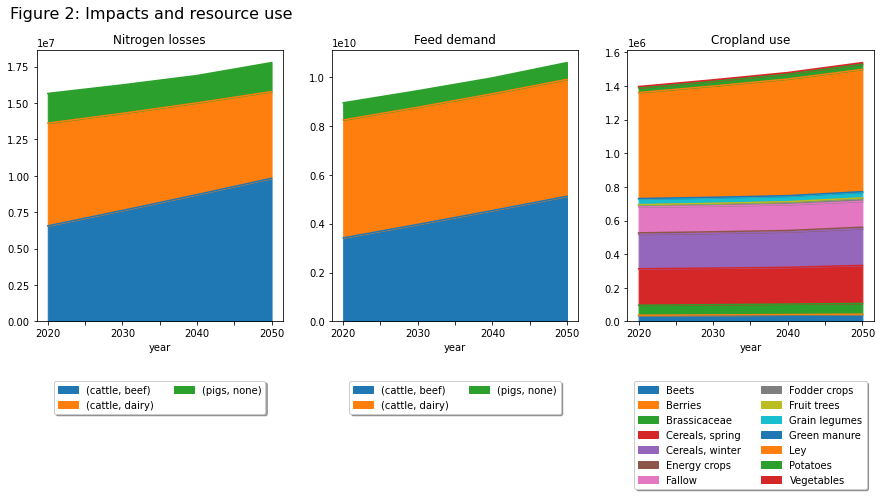

In [116]:
## FIGURE 1 --------------------->

# Number of animal heads
plot_data = pd.concat(
    [
        output.loc[(scn,y),'ani'].heads.groupby(['species','breed','animal'],axis=1).sum().sum() for y in years
    ],
    axis=1
).T
plot_data.index = pd.Index(years,name='year')

idxs = plot_data.columns.droplevel('animal').unique()

fig, axs = plt.subplots(1,len(idxs), figsize=(14,5))
n = 0

for idx in idxs:
    
    ax=axs[n]
    
    (
        plot_data.xs(idx,level=['species','breed'],axis=1).
        reset_index().plot.area(x='year', ax = ax, stacked=True)
    )
    
    ax.set_title(', '.join(idx),color='black')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2),
          ncol=2, fancybox=True, shadow=True)
    
    n += 1
        
plt.suptitle('Figure 1: Number of heads', fontsize=16, x=0.1, y=1, horizontalalignment='left')
plt.show()

## FIGURE 2 --------------------->
# N losses

plot_data = pd.concat(
    [
        output.loc[(scn,y),'ani'].manure.N_loss.groupby(['species','breed'],axis=1).sum().sum() for y in years
    ],
    axis=1
).T
plot_data.index = pd.Index(years,name='year')

fig, axs = plt.subplots(1,3, figsize=(15,5))

(
    plot_data.reset_index()
    .plot.area(x='year', ax = axs[0], stacked=True)
)

axs[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.2),
      ncol=2, fancybox=True, shadow=True)
        
axs[0].set_title('Nitrogen losses')

# Feed demand

plot_data = pd.concat(
    [
        output.loc[(scn,y),'ani'].feed.crop_product_demand.groupby(['species','breed'],axis=1).sum().sum() for y in years
    ],
    axis=1
).T
plot_data.index = pd.Index(years,name='year')

(
    plot_data.reset_index()
    .plot.area(x='year', ax = axs[1], stacked=True)
)

axs[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.2),
      ncol=2, fancybox=True, shadow=True)

axs[1].set_title('Feed demand')

# Cropland use

# crop --> crop_group
cg_rel = pd.Series(crops.par.get_rel('crop','crop_group')).rename('crop_group').rename_axis('crop')
# crop --> land_use
lu_rel = pd.Series(crops.par.get_rel('crop','land_use')).rename('land_use').rename_axis('crop')

idx = pd.IndexSlice

plot_data = pd.concat([
    (
        output.loc[(scn,y),'crp'].area.rename('area')
        .to_frame().join(cg_rel).join(lu_rel)
        .set_index('land_use', append=True)
        .loc[idx[:,:,:,'cropland']]
        .groupby('crop_group').sum()['area']
    )
    for y in years
], axis=1).T
plot_data.index = pd.Index(years,name='year')
(
    plot_data.reset_index()
    .plot.area(x='year', ax = axs[2], stacked=True)
)

axs[2].legend(loc='upper center', bbox_to_anchor=(0.5, -0.2),
      ncol=2, fancybox=True, shadow=True)

axs[2].set_title('Cropland use')

plt.suptitle('Figure 2: Impacts and resource use', fontsize=16, x=0.1, y=1, horizontalalignment='left')
plt.show()